In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

import warnings
warnings.filterwarnings('ignore')
import os


In [2]:
plt.rcParams.update({
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#141414',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2a2a2a',
    'figure.dpi':       130
})

COKE_RED   = '#F40009'
COKE_DARK  = '#8B0000'
BULL_COLOR = '#26a69a'
BEAR_COLOR = '#ef5350'
PALETTE    = [COKE_RED, '#FF6B6B', '#FF9A3C', '#FFD60A', '#ffffff',
              '#26a69a', '#42a5f5', '#ab47bc', '#66bb6a', '#8d6e63']

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
df = pd.read_csv('data.csv')
print(df.head())

         Date    Open    High     Low   Close   Volume  Daily_Return_Pct  \
0  1980-01-02  0.1937  0.1944  0.1895  0.1895  3451200               NaN   
1  1980-01-03  0.1895  0.1951  0.1881  0.1944  3960000            2.5858   
2  1980-01-04  0.1944  0.1965  0.1937  0.1965  1694400            1.0802   
3  1980-01-07  0.1965  0.1972  0.1951  0.1958  4396800           -0.3562   
4  1980-01-08  0.1958  0.1979  0.1958  0.1972  3244800            0.7150   

   Daily_Range  MA_20  MA_50  ...  BB_Upper  BB_Lower  BB_Width  RSI_14  \
0       0.0049    NaN    NaN  ...       NaN       NaN       NaN     NaN   
1       0.0070    NaN    NaN  ...       NaN       NaN       NaN     NaN   
2       0.0028    NaN    NaN  ...       NaN       NaN       NaN     NaN   
3       0.0021    NaN    NaN  ...       NaN       NaN       NaN     NaN   
4       0.0021    NaN    NaN  ...       NaN       NaN       NaN     NaN   

   Volume_MA_20  Cumulative_Return_Pct  Year  Month  Quarter  Day_of_Week  
0           NaN 

In [4]:
df.head()

,Date,Open,High,Low,Close,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,...,BB_Upper,BB_Lower,BB_Width,RSI_14,Volume_MA_20,Cumulative_Return_Pct,Year,Month,Quarter,Day_of_Week
0,1980-01-02,0.1937,0.1944,0.1895,0.1895,3451200,NaN,0.0049,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.00,1980,1,1,Wednesday
1,1980-01-03,0.1895,0.1951,0.1881,0.1944,3960000,2.5858,0.0070,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.59,1980,1,1,Thursday
2,1980-01-04,0.1944,0.1965,0.1937,0.1965,1694400,1.0802,0.0028,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.69,1980,1,1,Friday
3,1980-01-07,0.1965,0.1972,0.1951,0.1958,4396800,-0.3562,0.0021,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.32,1980,1,1,Monday
4,1980-01-08,0.1958,0.1979,0.1958,0.1972,3244800,0.7150,0.0021,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.06,1980,1,1,Tuesday


In [5]:
df.shape

(11615, 25)

In [6]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 11615 entries, 0 to 11614
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   11615 non-null  str    
 1   Open                   11615 non-null  float64
 2   High                   11615 non-null  float64
 3   Low                    11615 non-null  float64
 4   Close                  11615 non-null  float64
 5   Volume                 11615 non-null  int64  
 6   Daily_Return_Pct       11614 non-null  float64
 7   Daily_Range            11615 non-null  float64
 8   MA_20                  11596 non-null  float64
 9   MA_50                  11566 non-null  float64
 10  MA_200                 11416 non-null  float64
 11  EMA_12                 11615 non-null  float64
 12  EMA_26                 11615 non-null  float64
 13  MACD                   11615 non-null  float64
 14  MACD_Signal            11615 non-null  float64
 15  BB_Upper     

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Date                       0
Open                       0
High                       0
Low                        0
Close                      0
Volume                     0
Daily_Return_Pct           1
Daily_Range                0
MA_20                     19
MA_50                     49
MA_200                   199
EMA_12                     0
EMA_26                     0
MACD                       0
MACD_Signal                0
BB_Upper                  19
BB_Lower                  19
BB_Width                  19
RSI_14                    14
Volume_MA_20              19
Cumulative_Return_Pct      0
Year                       0
Month                      0
Quarter                    0
Day_of_Week                0
dtype: int64

In [9]:
df.columns = df.columns.str.lower().str.replace(' ','_')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.dropna(inplace=True)

adj_col = [c for c in df.columns if 'adj' in c]
if adj_col:
    df.rename(columns={adj_col[0]: 'adj_close'}, inplace=True)
else:
    df['adj_close'] = df['close']

print(f'Date range    : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Trading days  : {len(df):,}')

Date range    : 1980-10-14 to 2026-01-30
Trading days  : 11,416


In [10]:
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%b')
df['quarter']     = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.day_name()
df['decade']      = (df['year'] // 10 * 10).astype(str) + 's'

df['daily_return']   = df['adj_close'].pct_change() * 100
df['log_return']     = np.log(df['adj_close'] / df['adj_close'].shift(1)) * 100
df['monthly_return'] = df['adj_close'].pct_change(21) * 100
df['yearly_return']  = df['adj_close'].pct_change(252) * 100

df['ma_20']  = df['adj_close'].rolling(20).mean()
df['ma_50']  = df['adj_close'].rolling(50).mean()
df['ma_100'] = df['adj_close'].rolling(100).mean()
df['ma_200'] = df['adj_close'].rolling(200).mean()

df['volatility_30d']  = df['daily_return'].rolling(30).std()
df['volatility_ann']  = df['daily_return'].rolling(252).std() * np.sqrt(252)

df['daily_range']     = df['high'] - df['low']
df['daily_range_pct'] = (df['daily_range'] / df['open']) * 100

df['rolling_max'] = df['adj_close'].cummax()
df['drawdown']    = (df['adj_close'] - df['rolling_max']) / df['rolling_max'] * 100

df['growth_of_1000'] = 1000 * (df['adj_close'] / df['adj_close'].iloc[0])

print('Feature engineering complete.')
print(f'Total features : {df.shape[1]}')
df.tail(5)

Feature engineering complete.
Total features : 39


,date,open,high,low,close,volume,daily_return_pct,daily_range,ma_20,ma_50,...,log_return,monthly_return,yearly_return,ma_100,volatility_30d,volatility_ann,daily_range_pct,rolling_max,drawdown,growth_of_1000
11610,2026-01-26,72.86,73.30,72.54,72.56,14017400,-0.4391,0.76,70.375,70.605540,...,-0.440045,3.850007,21.405398,68.940385,1.048643,17.802523,1.043096,72.88,-0.439078,384525.702173
11611,2026-01-27,72.44,73.56,72.27,73.55,13239200,1.3644,1.29,70.559,70.656316,...,1.355164,4.906575,22.286788,68.996011,1.022771,17.840158,1.780784,73.55,0.000000,389772.125066
11612,2026-01-28,73.21,73.62,72.57,73.06,14633700,-0.6662,1.05,70.704,70.706030,...,-0.668443,4.565622,17.763493,69.054029,0.974233,17.588685,1.434230,73.55,-0.666213,387175.410705
11613,2026-01-29,73.18,74.09,73.14,73.43,20862100,0.5064,0.95,70.872,70.761356,...,0.505155,4.660775,21.225829,69.118605,0.972125,17.423142,1.298169,73.55,-0.163154,389136.195019
11614,2026-01-30,73.71,74.90,73.54,74.81,26420500,1.8793,1.36,71.117,70.853816,...,1.861899,6.764664,22.580265,69.202204,1.005697,17.502867,1.845069,74.81,0.000000,396449.390567


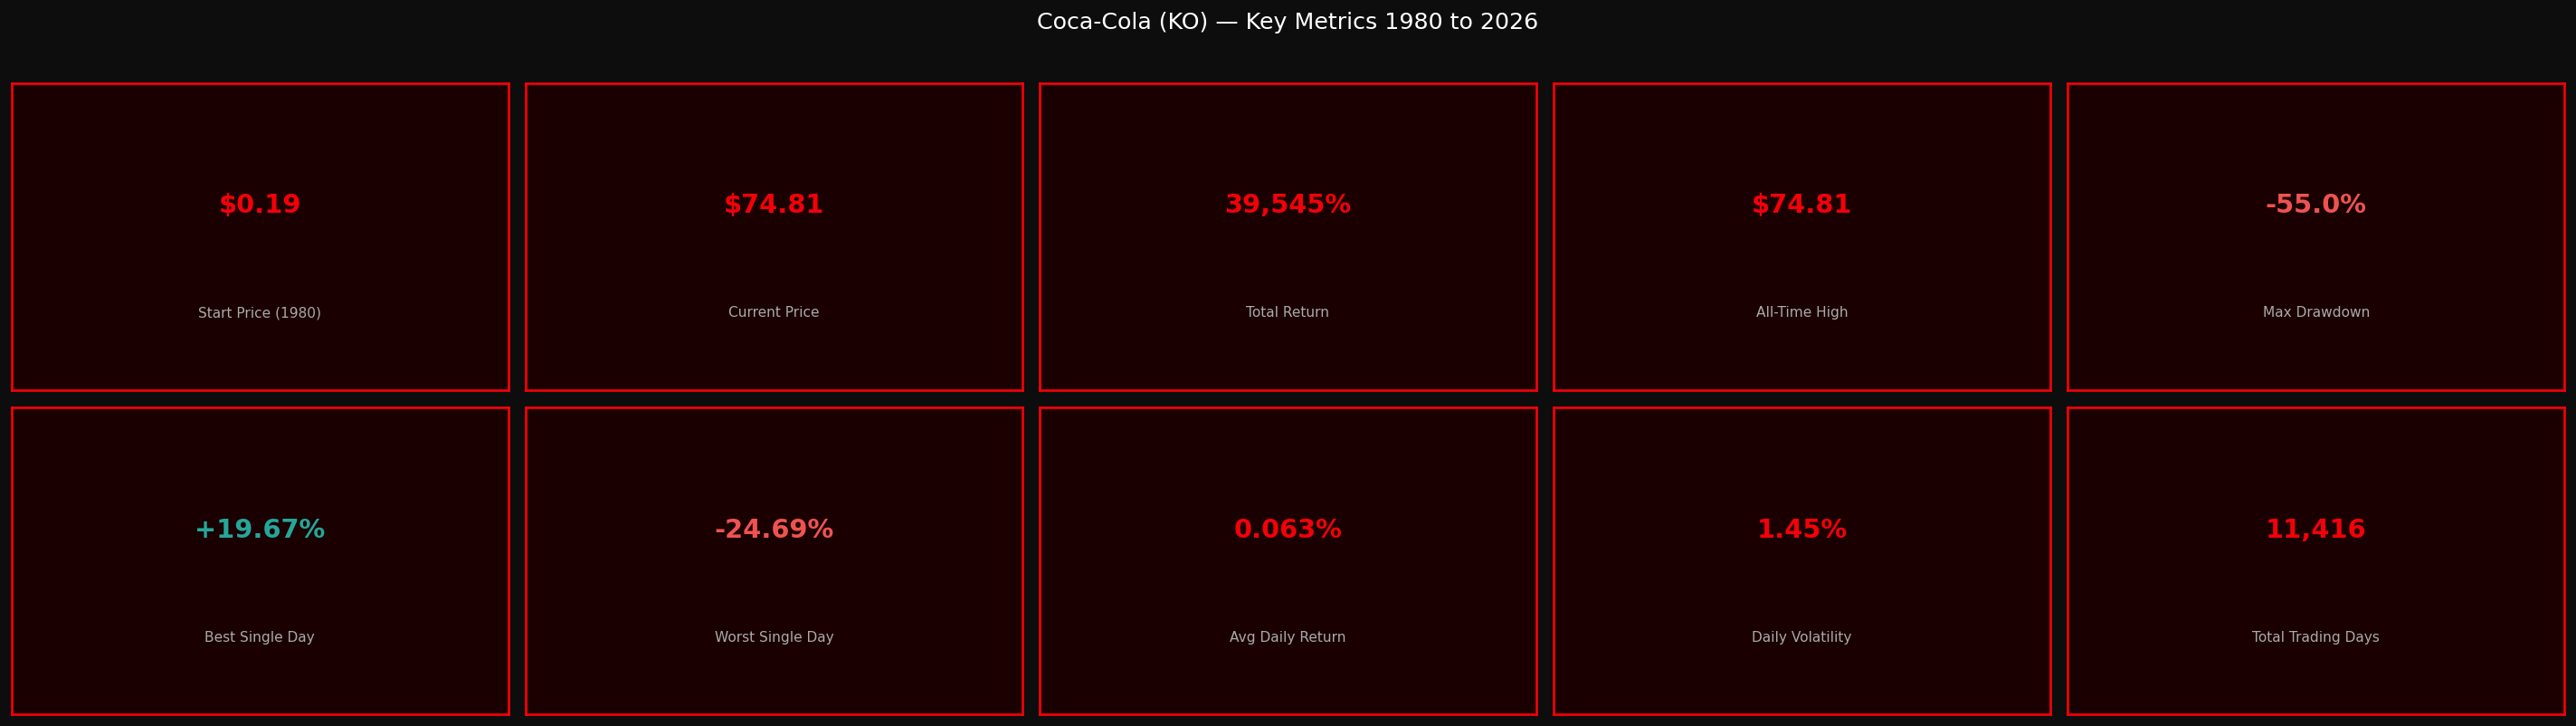

In [11]:
start_price   = df['adj_close'].iloc[0]
end_price     = df['adj_close'].iloc[-1]
total_return  = ((end_price - start_price) / start_price) * 100
max_price     = df['adj_close'].max()
min_price     = df['adj_close'].min()
avg_volume    = df['volume'].mean()
max_drawdown  = df['drawdown'].min()
avg_daily_ret = df['daily_return'].mean()
std_daily_ret = df['daily_return'].std()
best_day      = df['daily_return'].max()
worst_day     = df['daily_return'].min()
trading_days  = len(df)

metrics = [
    ('Start Price (1980)',   f'${start_price:.2f}'),
    ('Current Price',        f'${end_price:.2f}'),
    ('Total Return',         f'{total_return:,.0f}%'),
    ('All-Time High',        f'${max_price:.2f}'),
    ('Max Drawdown',         f'{max_drawdown:.1f}%'),
    ('Best Single Day',      f'+{best_day:.2f}%'),
    ('Worst Single Day',     f'{worst_day:.2f}%'),
    ('Avg Daily Return',     f'{avg_daily_ret:.3f}%'),
    ('Daily Volatility',     f'{std_daily_ret:.2f}%'),
    ('Total Trading Days',   f'{trading_days:,}')
]

fig, axes = plt.subplots(2, 5, figsize=(22, 6))
fig.patch.set_facecolor('#0d0d0d')
axes = axes.flatten()

for ax, (label, value) in zip(axes, metrics):
    ax.set_facecolor('#1a0000')
    color = '#26a69a' if '+' in str(value) and 'Day' in label else \
            '#ef5350' if '-' in str(value) else COKE_RED
    ax.text(0.5, 0.60, value, ha='center', va='center',
            fontsize=16, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=8.5, color='#aaaaaa', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(COKE_RED)
        spine.set_linewidth(1.5)

plt.suptitle('Coca-Cola (KO) — Key Metrics 1980 to 2026',
             fontsize=14, color='white', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
fig = make_subplots(
    rows = 2, cols = 1,
    shared_xaxes = True,
    row_heights = [0.7, 0.3],
    subplot_titles=['KO Adjusted Close Price (1980–2026)', 'Trading Volume']
)

fig.add_trace(
    go.Scatter(x=df['date'], y=df['adj_close'],
               line=dict(color=COKE_RED, width=1.5),
               name='Adj Close', fill='tozeroy',
               fillcolor='rgba(244,0,9,0.08)'),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df['date'], y=df['ma_200'],
               line=dict(color='#FFD60A', width=1.2, dash='dot'),
               name='200-Day MA'),
    row=1, col=1
)

colors = [BULL_COLOR if r >= 0 else BEAR_COLOR
          for r in df['daily_return'].fillna(0)]
fig.add_trace(
    go.Bar(x=df['date'], y=df['volume'],
           marker_color=colors, opacity=0.6, name='Volume'),
    row=2, col=1
)
events = [
    ('1987-10-19', 'Black Monday'),
    ('2000-01-01', 'Dot-com Bust'),
    ('2008-09-15', '2008 Crisis'),
    ('2020-03-16', 'COVID Crash'),
]
for date_str, label in events:
    date_val = pd.to_datetime(date_str)
    row_match = df[df['date'] >= date_val]
    if not row_match.empty:
        price_at = row_match.iloc[0]['adj_close']
        fig.add_annotation(
            x=date_val, y=price_at,
            text=label, showarrow=True,
            arrowhead=2, arrowcolor='#FFD60A',
            font=dict(color='#FFD60A', size=10),
            ax=0, ay=-40, row=1, col=1
        )

fig.update_layout(
    template='plotly_dark',
    height=600,
    hovermode='x unified',
    showlegend=True,
    legend=dict(orientation='h', y=1.05)
)
fig.update_yaxes(title_text='Price (USD)', row=1, col=1)
fig.update_yaxes(title_text='Volume', row=2, col=1)
fig.show()

In [15]:
vol_year = df.groupby('year')['volume'].mean().reset_index()

fig = px.bar(
    vol_year, x='year', y='volume',
    color='volume', color_continuous_scale='Reds',
    title='Average Daily Trading Volume by Year',
    labels={'volume': 'Avg Daily Volume', 'year': 'Year'},
    text=vol_year['volume'].apply(lambda x: f'{x/1e6:.0f}M')
)

fig.update_traces(textposition='outside')
fig.update_layout(template = 'plotly_dark', coloraxis_showscale = False)
fig.show()

In [18]:
top_vol = df.nlargest(20 , 'volume')[['date', 'volume', 'adj_close', 'daily_return']]
top_vol['volume_M'] = (top_vol['volume'] / 1e6).round(1)
top_vol['daily_return'] = top_vol['daily_return'].round(2)

fig = px.bar(
    top_vol, x='date', y='volume_M',
    color='daily_return',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    title='Top 20 Highest Volume Days in KO History (colored by Daily Return)',
    labels={'volume_M': 'Volume (Millions)', 'date': 'Date', 'daily_return': 'Daily Return %'},
    hover_data=['adj_close', 'daily_return']
)

fig.update_layout(template = 'plotly_dark')

fig.show()

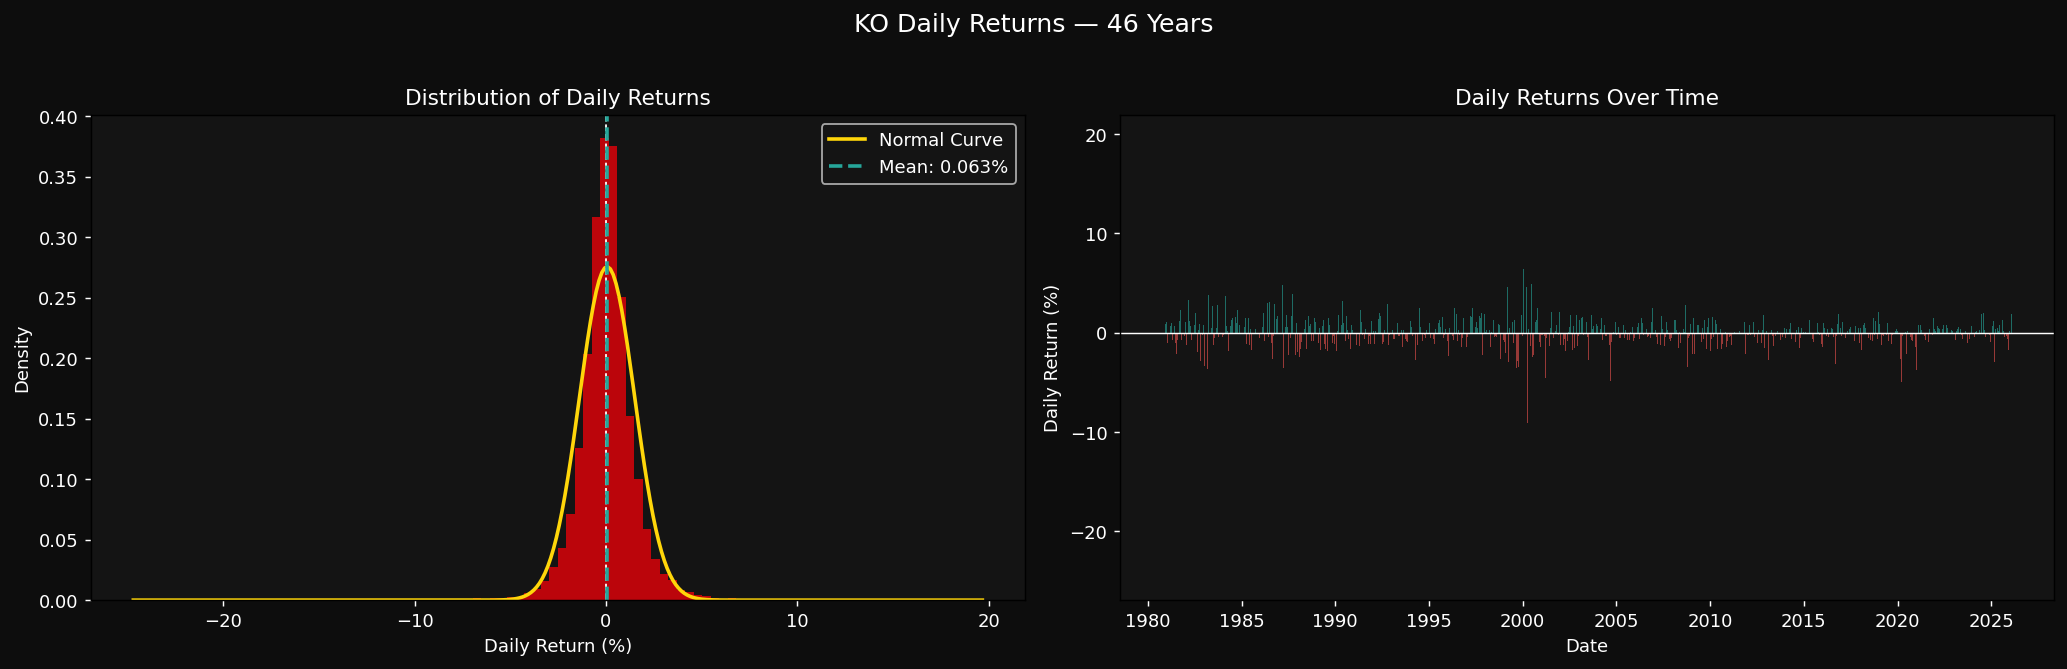

In [19]:
returns = df['daily_return'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d0d0d')

ax = axes[0]
ax.set_facecolor('#141414')
ax.hist(returns, bins=100, color=COKE_RED, alpha=0.75, edgecolor='none', density=True)
from scipy.stats import norm
mu, std = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 300)
ax.plot(x, norm.pdf(x, mu, std), color='#FFD60A', lw=2, label='Normal Curve')
ax.axvline(0, color='white', lw=1, linestyle='--')
ax.axvline(mu, color='#26a69a', lw=2, linestyle='--', label=f'Mean: {mu:.3f}%')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Daily Returns')
ax.legend()

ax2 = axes[1]
ax2.set_facecolor('#141414')
colors = [BULL_COLOR if r >= 0 else BEAR_COLOR for r in returns]
ax2.bar(df['date'].iloc[1:], returns, color=colors, alpha=0.6, width=1)
ax2.axhline(0, color='white', lw=0.8)
ax2.set_xlabel('Date')
ax2.set_ylabel('Daily Return (%)')
ax2.set_title('Daily Returns Over Time')

plt.suptitle('KO Daily Returns — 46 Years', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [22]:
stats = pd.DataFrame({
    'Metric': ['Mean Daily Return', 'Median Daily Return', 'Std Dev',
               'Best Day Ever', 'Worst Day Ever',
               'Positive Days', 'Negative Days', 'Skewness', 'Kurtosis'],
    'Value': [
        f'{returns.mean():.4f}%',
        f'{returns.median():.4f}%',
        f'{returns.std():.4f}%',
        f'+{returns.max():.2f}% on {df.loc[returns.idxmax(), "date"].date()}',
        f'{returns.min():.2f}% on {df.loc[returns.idxmin(), "date"].date()}',
        f'{(returns > 0).sum():,} days ({(returns > 0).mean()*100:.1f}%)',
        f'{(returns < 0).sum():,} days ({(returns < 0).mean()*100:.1f}%)',
        f'{returns.skew():.4f}',
        f'{returns.kurt():.4f}'
    ]
})
display(stats.style.set_properties(**{'text-align': 'left'}))

,Metric,Value
0,Mean Daily Return,0.0629%
1,Median Daily Return,0.0183%
2,Std Dev,1.4478%
3,Best Day Ever,+19.67% on 1987-10-20
4,Worst Day Ever,-24.69% on 1987-10-19
5,Positive Days,"5,722 days (50.1%)"
6,Negative Days,"5,283 days (46.3%)"
7,Skewness,-0.0994
8,Kurtosis,15.8005


In [23]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['KO Price', '30-Day Rolling Volatility (%)'],
                    row_heights=[0.6, 0.4])

fig.add_trace(
    go.Scatter(x=df['date'], y=df['adj_close'],
               line=dict(color=COKE_RED, width=1),
               name='Price'),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=df['date'], y=df['volatility_30d'],
               line=dict(color='#FF9A3C', width=1.5),
               fill='tozeroy', fillcolor='rgba(255,154,60,0.15)',
               name='30D Volatility'),
    row=2, col=1
)
fig.update_layout(
    title='Volatility Spikes vs Price Movement — Crises Stand Out Clearly',
    template='plotly_dark', height=550, hovermode='x unified'
)
fig.show()

In [24]:
vol_decade = df.groupby('decade')['daily_return'].std() * np.sqrt(252)
vol_decade = vol_decade.reset_index()
vol_decade.columns = ['decade', 'ann_volatility']

fig = px.bar(
    vol_decade, x='decade', y='ann_volatility',
    color='ann_volatility', color_continuous_scale='Reds',
    title='Annualised Volatility by Decade — Which Era Was the Riskiest?',
    labels={'ann_volatility': 'Annualised Volatility (%)', 'decade': 'Decade'},
    text=vol_decade['ann_volatility'].apply(lambda x: f'{x:.1f}%')
)
fig.update_traces(textposition='outside')
fig.update_layout(template='plotly_dark', coloraxis_showscale=False)
fig.show()

In [25]:
recent = df[df['year'] >= df['year'].max() - 5]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recent['date'], y=recent['adj_close'],
    name='Adj Close', line=dict(color='white', width=1.2)
))
fig.add_trace(go.Scatter(
    x=recent['date'], y=recent['ma_20'],
    name='MA 20', line=dict(color='#42a5f5', width=1.2, dash='dot')
))
fig.add_trace(go.Scatter(
    x=recent['date'], y=recent['ma_50'],
    name='MA 50', line=dict(color='#FFD60A', width=1.5)
))
fig.add_trace(go.Scatter(
    x=recent['date'], y=recent['ma_200'],
    name='MA 200', line=dict(color=COKE_RED, width=2)
))

cross = recent.copy().dropna(subset=['ma_50','ma_200'])
cross['signal'] = np.where(cross['ma_50'] > cross['ma_200'], 1, -1)
cross['cross']  = cross['signal'].diff()

golden = cross[cross['cross'] == 2]
death  = cross[cross['cross'] == -2]

for _, row in golden.iterrows():
    fig.add_annotation(x=row['date'], y=row['adj_close'],
                       text='Golden Cross', showarrow=True,
                       arrowcolor='#FFD60A', font=dict(color='#FFD60A', size=10),
                       ax=0, ay=-50)
for _, row in death.iterrows():
    fig.add_annotation(x=row['date'], y=row['adj_close'],
                       text='Death Cross', showarrow=True,
                       arrowcolor='#ef5350', font=dict(color='#ef5350', size=10),
                       ax=0, ay=50)

fig.update_layout(
    title='Moving Averages — Golden Cross and Death Cross Signals (Last 5 Years)',
    template='plotly_dark', height=500, hovermode='x unified'
)
fig.show()

In [27]:
last_year = df[df['date'] >= df['date'].max() - pd.DateOffset(months=12)]

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    row_heights=[0.7, 0.3],
                    subplot_titles=['KO Candlestick — Last 12 Months', 'Volume'])

fig.add_trace(
    go.Candlestick(
        x=last_year['date'],
        open=last_year['open'],
        high=last_year['high'],
        low=last_year['low'],
        close=last_year['close'],
        increasing_line_color=BULL_COLOR,
        decreasing_line_color=BEAR_COLOR,
        name='KO'
    ), row=1, col=1
)
fig.add_trace(
    go.Bar(
        x=last_year['date'],
        y=last_year['volume'],
        marker_color=[BULL_COLOR if r >= 0 else BEAR_COLOR
                      for r in last_year['daily_return'].fillna(0)],
        name='Volume'
    ), row=2, col=1
)

fig.update_layout(
    template='plotly_dark', height=550,
    xaxis_rangeslider_visible=False
)
fig.show()

In [28]:
decade_stats = df.groupby('decade').agg(
    start_price  = ('adj_close', 'first'),
    end_price    = ('adj_close', 'last'),
    avg_volume   = ('volume', 'mean'),
    avg_vol_30d  = ('volatility_30d', 'mean'),
    trading_days = ('date', 'count')
).reset_index()

decade_stats['total_return_%'] = (
    (decade_stats['end_price'] - decade_stats['start_price'])
    / decade_stats['start_price'] * 100
).round(2)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Total Return % by Decade',
                                    'Avg Daily Volume by Decade'])

colors_ret = [BULL_COLOR if v >= 0 else BEAR_COLOR
              for v in decade_stats['total_return_%']]

fig.add_trace(
    go.Bar(x=decade_stats['decade'], y=decade_stats['total_return_%'],
           marker_color=colors_ret, name='Return %',
           text=decade_stats['total_return_%'].apply(lambda x: f'{x:+.1f}%'),
           textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=decade_stats['decade'],
           y=decade_stats['avg_volume'] / 1e6,
           marker_color=COKE_RED, name='Volume (M)',
           text=(decade_stats['avg_volume']/1e6).apply(lambda x: f'{x:.0f}M'),
           textposition='outside'),
    row=1, col=2
)
fig.add_hline(y=0, line_dash='dash', line_color='white', row=1, col=1)
fig.update_layout(title='KO Performance Decade by Decade',
                  template='plotly_dark', height=450, showlegend=False)
fig.show()

display(decade_stats[['decade','start_price','end_price','total_return_%','trading_days']])

,decade,start_price,end_price,total_return_%,trading_days
0,1980s,0.1887,2.0386,980.34,2329
1,1990s,2.0583,14.0678,583.47,2528
2,2000s,13.6150,17.4232,27.97,2515
3,2010s,17.4354,46.0446,164.09,2516
4,2020s,45.7451,74.8100,63.54,1528


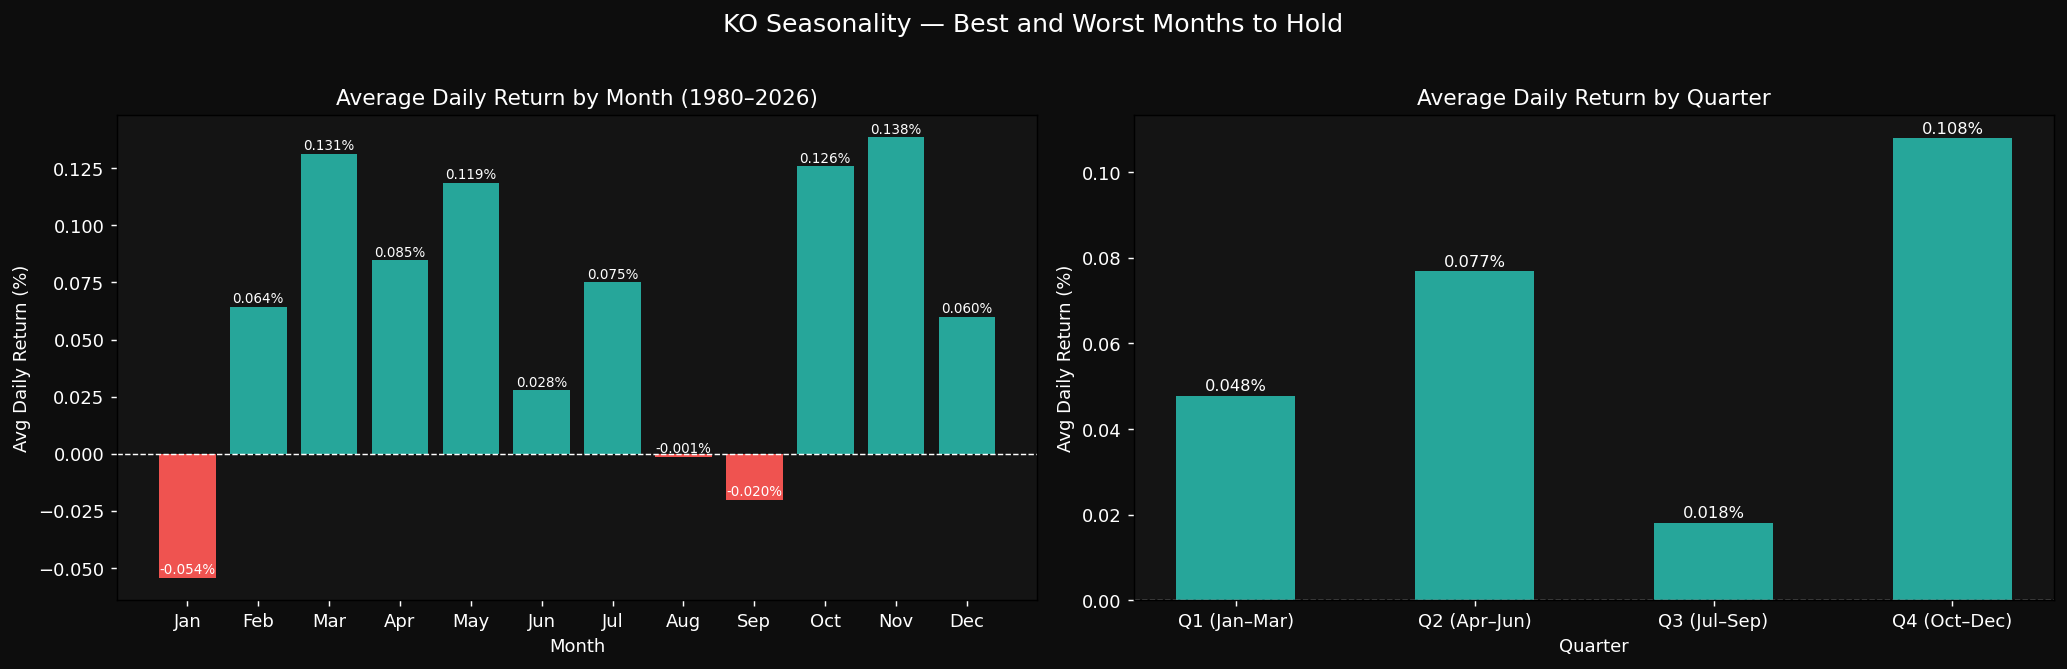

In [31]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_ret = (
    df.groupby('month_name')['daily_return']
      .mean()
      .reindex(month_order)
      .reset_index()
)
monthly_ret.columns = ['month', 'avg_daily_return']

colors_m = [BULL_COLOR if v >= 0 else BEAR_COLOR
            for v in monthly_ret['avg_daily_return']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d0d0d')

ax = axes[0]
ax.set_facecolor('#141414')
bars = ax.bar(monthly_ret['month'], monthly_ret['avg_daily_return'],
              color=colors_m, edgecolor='none')
ax.axhline(0, color='white', lw=0.8, linestyle='--')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Daily Return (%)')
ax.set_title('Average Daily Return by Month (1980–2026)')
for bar, val in zip(bars, monthly_ret['avg_daily_return']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{val:.3f}%', ha='center', va='bottom', fontsize=7.5)

q_ret = df.groupby('quarter')['daily_return'].mean().reset_index()
q_ret.columns = ['quarter', 'avg_return']
q_ret['quarter_label'] = q_ret['quarter'].map(
    {1: 'Q1 (Jan–Mar)', 2: 'Q2 (Apr–Jun)',
     3: 'Q3 (Jul–Sep)', 4: 'Q4 (Oct–Dec)'})

ax2 = axes[1]
ax2.set_facecolor('#141414')
colors_q = [BULL_COLOR if v >= 0 else BEAR_COLOR for v in q_ret['avg_return']]
bars2 = ax2.bar(q_ret['quarter_label'], q_ret['avg_return'],
                color=colors_q, edgecolor='none', width=0.5)
ax2.axhline(0, color='white', lw=0.8, linestyle='--')
ax2.set_xlabel('Quarter')
ax2.set_ylabel('Avg Daily Return (%)')
ax2.set_title('Average Daily Return by Quarter')
for bar, val in zip(bars2, q_ret['avg_return']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0005,
             f'{val:.3f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('KO Seasonality — Best and Worst Months to Hold',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ko_monthly_return_quarterly_return.png', dpi=150, bbox_inches='tight')
plt.show()

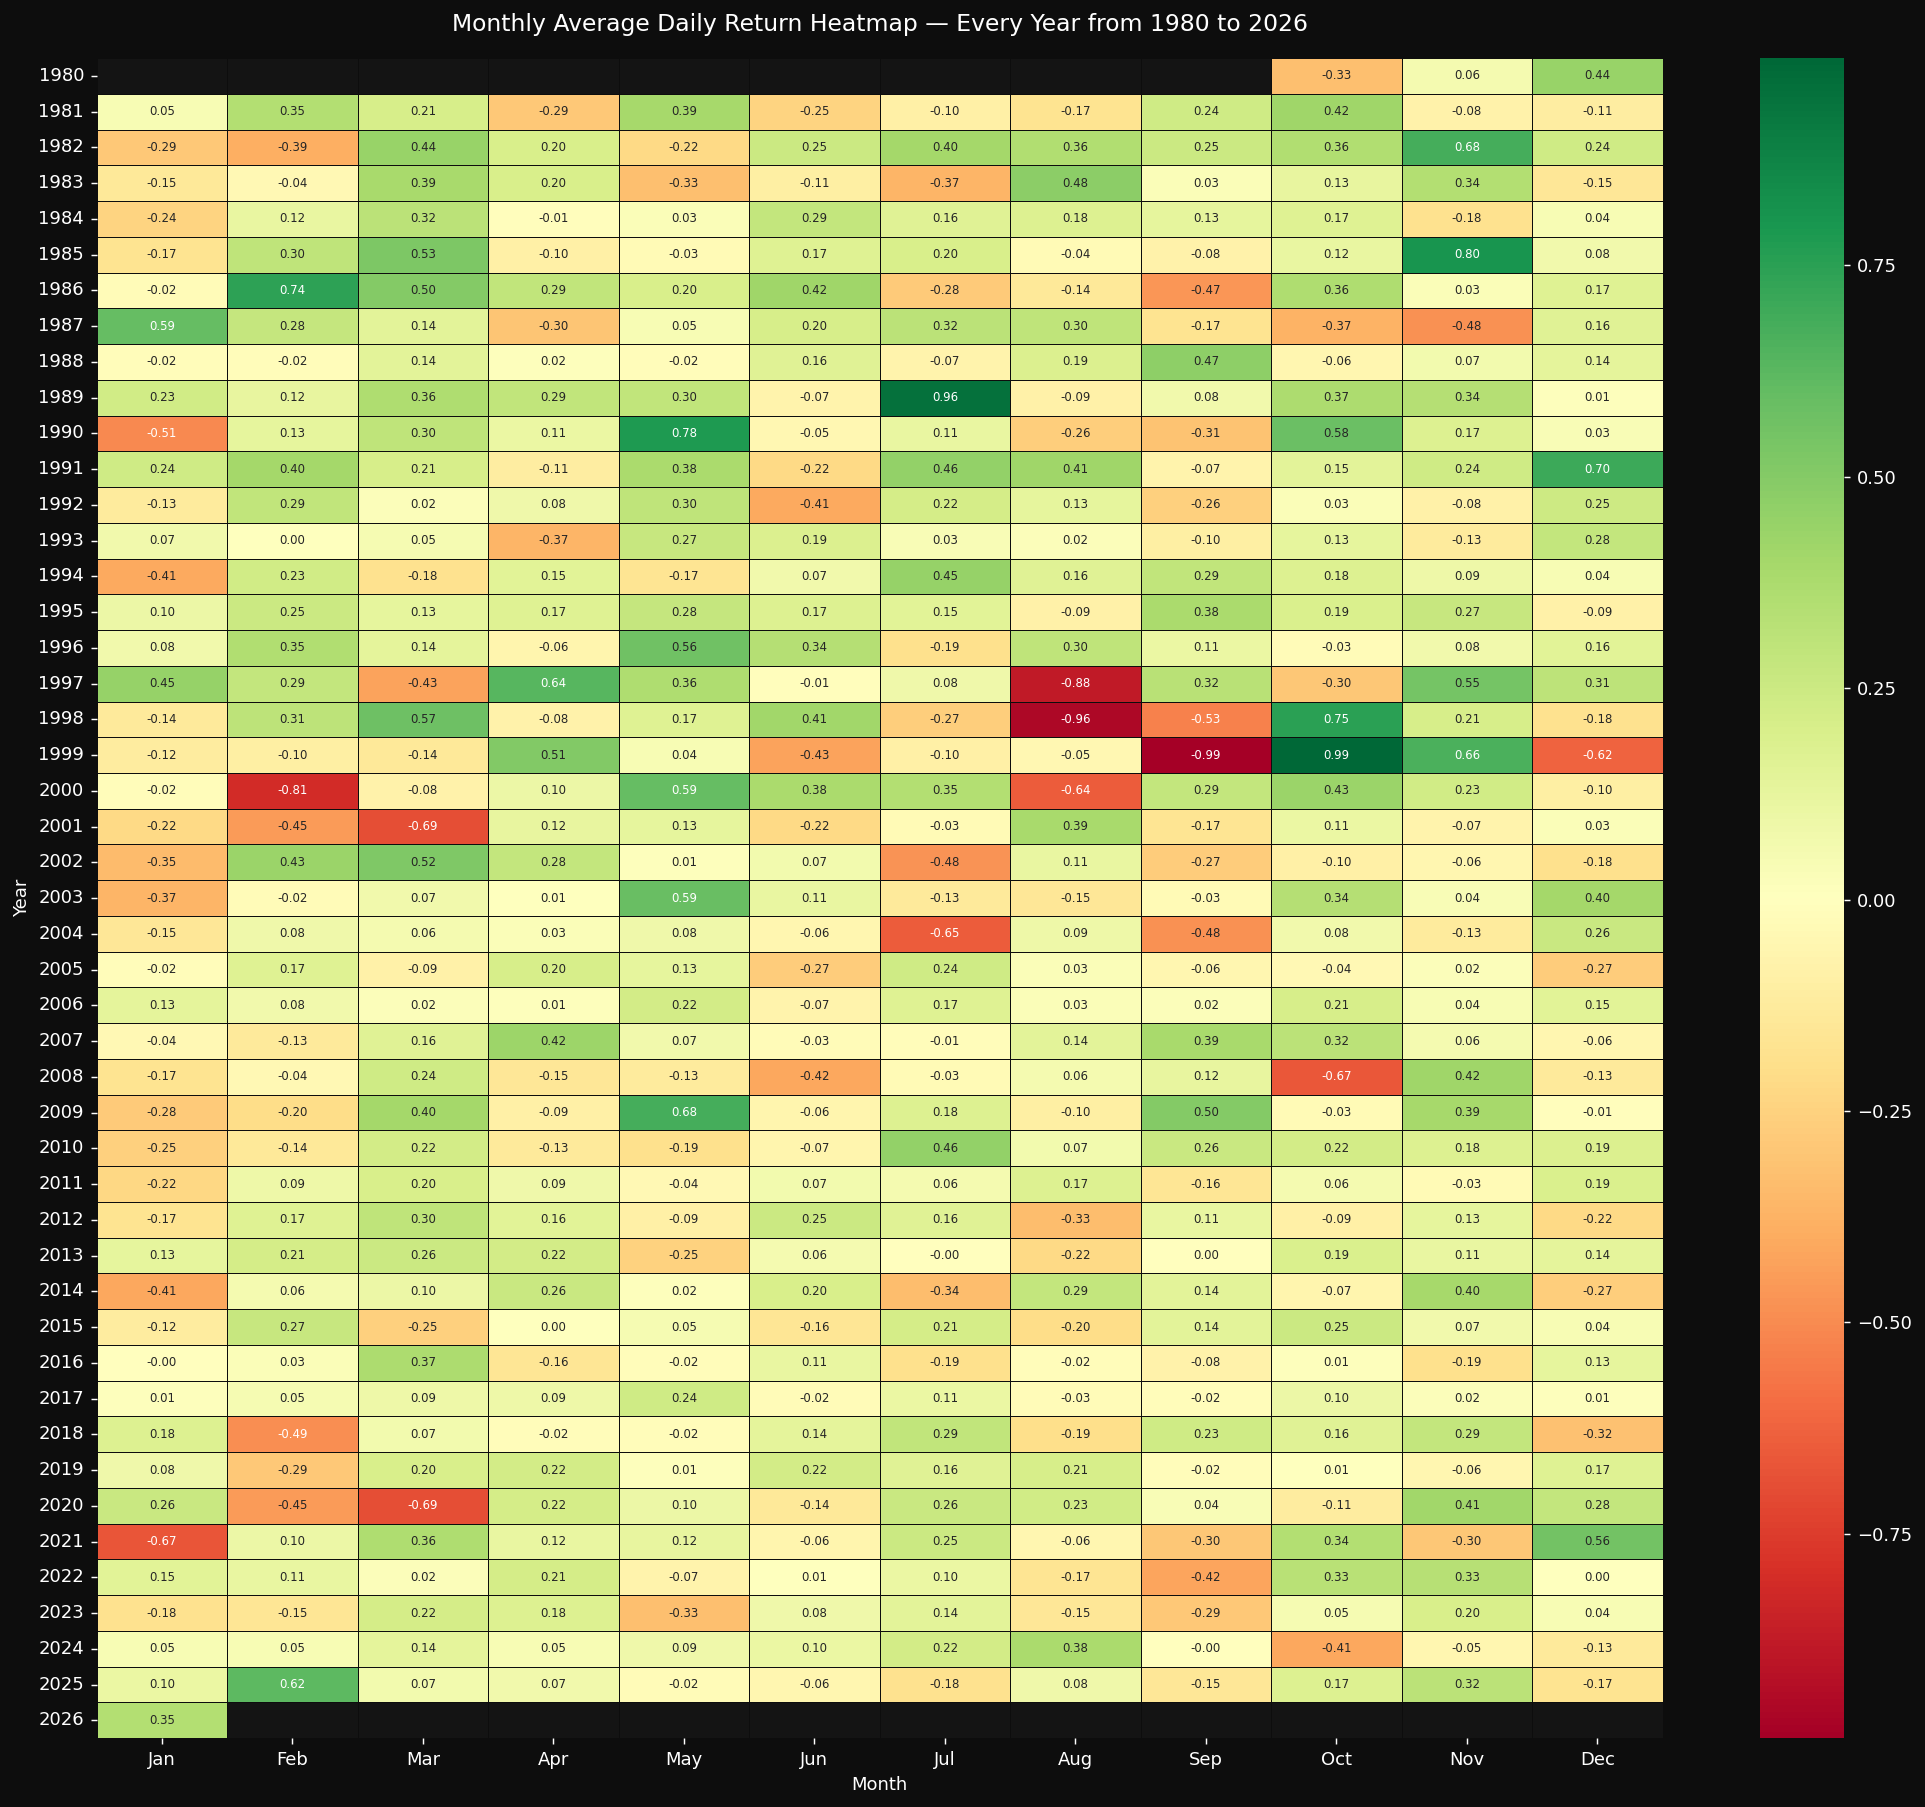

In [30]:
pivot = df.pivot_table(
    index='year', columns='month_name',
    values='daily_return', aggfunc='mean'
)[month_order]

fig, ax = plt.subplots(figsize=(16, 14))
ax.set_facecolor('#141414')
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, ax=ax, linewidths=0.3,
    linecolor='#0d0d0d', annot_kws={'size': 6.5}
)
ax.set_title('Monthly Average Daily Return Heatmap — Every Year from 1980 to 2026',
             fontsize=13, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('ko_monthly_return_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['KO Price vs All-Time High',
                                    'Drawdown from Peak (%)'],
                    row_heights=[0.55, 0.45])

fig.add_trace(
    go.Scatter(x=df['date'], y=df['adj_close'],
               name='Price', line=dict(color=COKE_RED, width=1)),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=df['date'], y=df['rolling_max'],
               name='All-Time High', line=dict(color='#FFD60A', width=1, dash='dot')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=df['date'], y=df['drawdown'],
               name='Drawdown %', fill='tozeroy',
               fillcolor='rgba(239,83,80,0.3)',
               line=dict(color=BEAR_COLOR, width=1)),
    row=2, col=1
)

max_dd_idx = df['drawdown'].idxmin()
fig.add_annotation(
    x=df.loc[max_dd_idx, 'date'],
    y=df.loc[max_dd_idx, 'drawdown'],
    text=f"Max Drawdown: {df.loc[max_dd_idx, 'drawdown']:.1f}%",
    showarrow=True, arrowcolor='white',
    font=dict(color='white', size=11),
    ax=60, ay=-40, row=2, col=1
)

fig.update_layout(
    title='KO Drawdown Analysis — How Bad Did It Get?',
    template='plotly_dark', height=550, hovermode='x unified'
)
fig.show()

In [33]:
final_value = df['growth_of_1000'].iloc[-1]
total_gain  = final_value - 1000
total_ret   = (final_value / 1000 - 1) * 100
years       = (df['date'].max() - df['date'].min()).days / 365.25
cagr        = ((final_value / 1000) ** (1/years) - 1) * 100

print(f'Initial Investment  : $1,000')
print(f'Final Value         : ${final_value:,.2f}')
print(f'Total Gain          : ${total_gain:,.2f}')
print(f'Total Return        : {total_ret:,.1f}%')
print(f'CAGR (annualised)   : {cagr:.2f}%')
print(f'Years Held          : {years:.1f}')

milestones = [2000, 5000, 10000, 25000, 50000]
milestone_dates = {}
for m in milestones:
    hit = df[df['growth_of_1000'] >= m]
    if not hit.empty:
        milestone_dates[m] = hit.iloc[0]['date']

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df['date'], y=df['growth_of_1000'],
        fill='tozeroy', fillcolor='rgba(244,0,9,0.1)',
        line=dict(color=COKE_RED, width=2),
        name='Portfolio Value'
    )
)

for m, d in milestone_dates.items():
    fig.add_annotation(
        x=d, y=m,
        text=f'${m:,}', showarrow=True,
        arrowcolor='#FFD60A', font=dict(color='#FFD60A', size=10),
        ax=40, ay=-30
    )

fig.add_hline(y=1000, line_dash='dash', line_color='white',
              annotation_text='Initial $1,000',
              annotation_font_color='white')

fig.update_layout(
    title=f'$1,000 invested in KO in 1980 → ${final_value:,.0f} today | CAGR: {cagr:.2f}%',
    xaxis_title='Year',
    yaxis_title='Portfolio Value ($)',
    template='plotly_dark',
    height=500
)
fig.show()

Initial Investment  : $1,000
Final Value         : $396,449.39
Total Gain          : $395,449.39
Total Return        : 39,544.9%
CAGR (annualised)   : 14.12%
Years Held          : 45.3


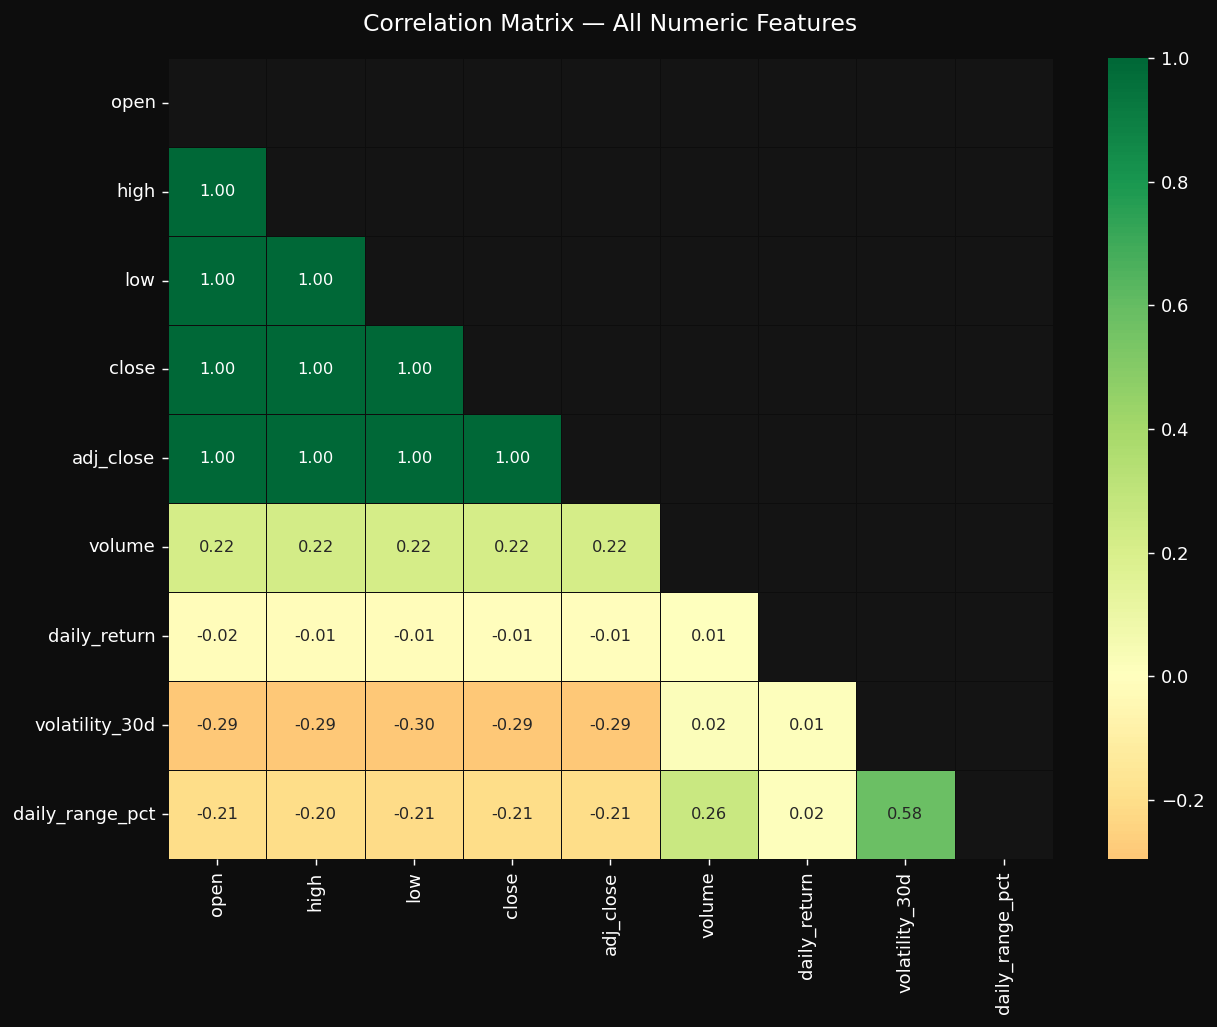

In [34]:
num_cols = ['open','high','low','close','adj_close','volume',
            'daily_return','volatility_30d','daily_range_pct']
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('#141414')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.5, linecolor='#0d0d0d',
    annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix — All Numeric Features', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('ko_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
dow_ret = (
    df[df['day_of_week'].isin(dow_order)]
      .groupby('day_of_week')['daily_return']
      .agg(['mean','std','count'])
      .reindex(dow_order)
      .reset_index()
)
dow_ret.columns = ['day','avg_return','std_return','count']

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Avg Return by Day of Week',
                                    'Volatility by Day of Week'])
colors_d = [BULL_COLOR if v >= 0 else BEAR_COLOR for v in dow_ret['avg_return']]

fig.add_trace(
    go.Bar(x=dow_ret['day'], y=dow_ret['avg_return'],
           marker_color=colors_d, name='Avg Return',
           text=dow_ret['avg_return'].apply(lambda x: f'{x:.4f}%'),
           textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=dow_ret['day'], y=dow_ret['std_return'],
           marker_color=COKE_RED, name='Std Dev',
           text=dow_ret['std_return'].apply(lambda x: f'{x:.3f}%'),
           textposition='outside'),
    row=1, col=2
)

fig.add_hline(y=0, line_dash='dash', line_color='white', row=1, col=1)
fig.update_layout(title='Does the Day of the Week Matter for KO Returns?',
                  template='plotly_dark', height=420, showlegend=False)
fig.show()